# Dynamic Programming: Policy Evaluation

This notebook runs policy evaluation on a deterministic GridWorld environment and visualizes the resulting state-value function, policy arrows, combined overlays, and convergence history.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))

from envs.grid_world import GridWorld
from algorithms.policy_evaluation import policy_evaluation
from algorithms.policy_iteration import initialize_pi_policy
from utils import (
    plot_value_grid,
    plot_policy_arrows,
    plot_value_and_policy,
    plot_convergence_comparison,
)

%matplotlib inline

## Environment Setup

The GridWorld environment uses deterministic transitions and fixed terminal states. We also create a random policy that will be evaluated without any improvement step.

In [2]:
env = GridWorld(n_rows=10, n_cols=15, seed=2026)

gamma = 0.95
seed = 84
pi = initialize_pi_policy(env, seed=seed)

print("Environment Configuration:")
print(f"  - Total Grid States: {len(env.states)}")
print(f"  - Terminal States: {env.terminal_states}")
print(f"  - Non-Terminal States: {len(env.non_terminal_states)}")
print(f"  - Available Actions: {env.ACTIONS}")
print("\nInitial policy sample:")
for state in env.non_terminal_states[:5]:
    print(f"  {state}: {pi[state]}")

Environment Configuration:
  - Total Grid States: 150
  - Terminal States: [(2, 0), (5, 6)]
  - Non-Terminal States: 148
  - Available Actions: ['up', 'down', 'left', 'right']

Initial policy sample:
  (0, 0): ['down', 'right', 'up']
  (0, 1): ['down', 'left', 'right']
  (0, 2): ['down', 'left', 'right']
  (0, 3): ['down', 'left', 'right', 'up']
  (0, 4): ['right', 'up']


## Policy Evaluation Run

We evaluate the fixed policy until the value function converges or the backup budget is exhausted.

Policy evaluation completed in 40256 Bellman backups.
Final delta value: 0.000001


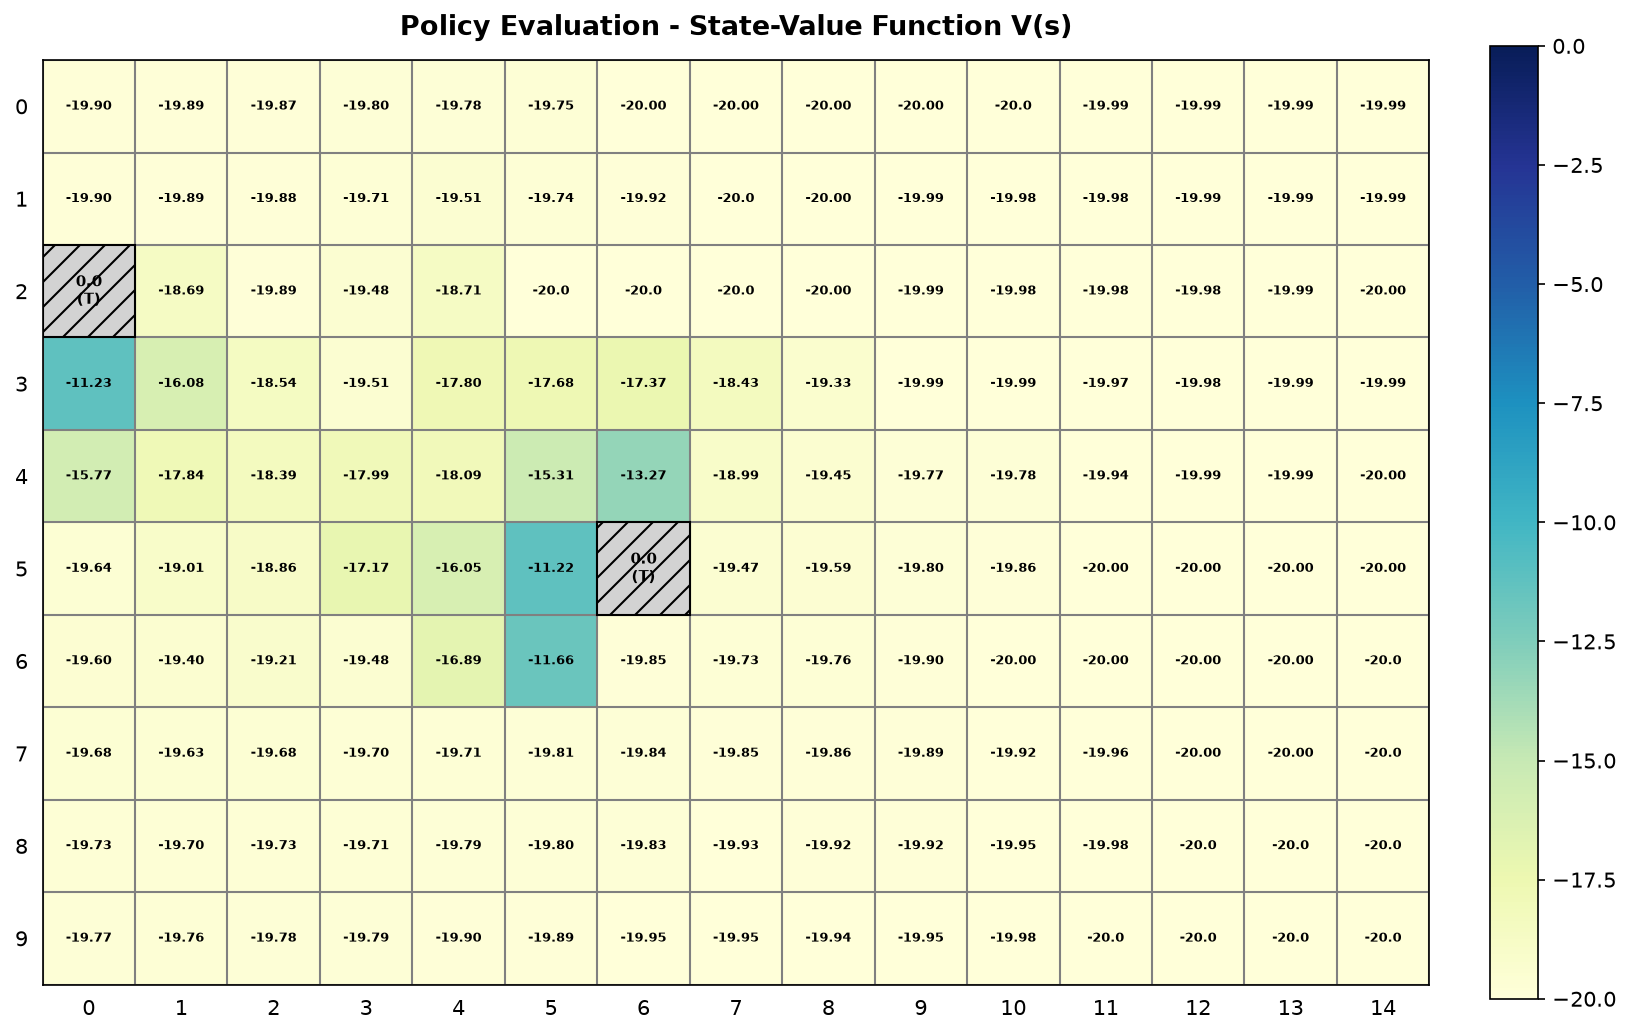

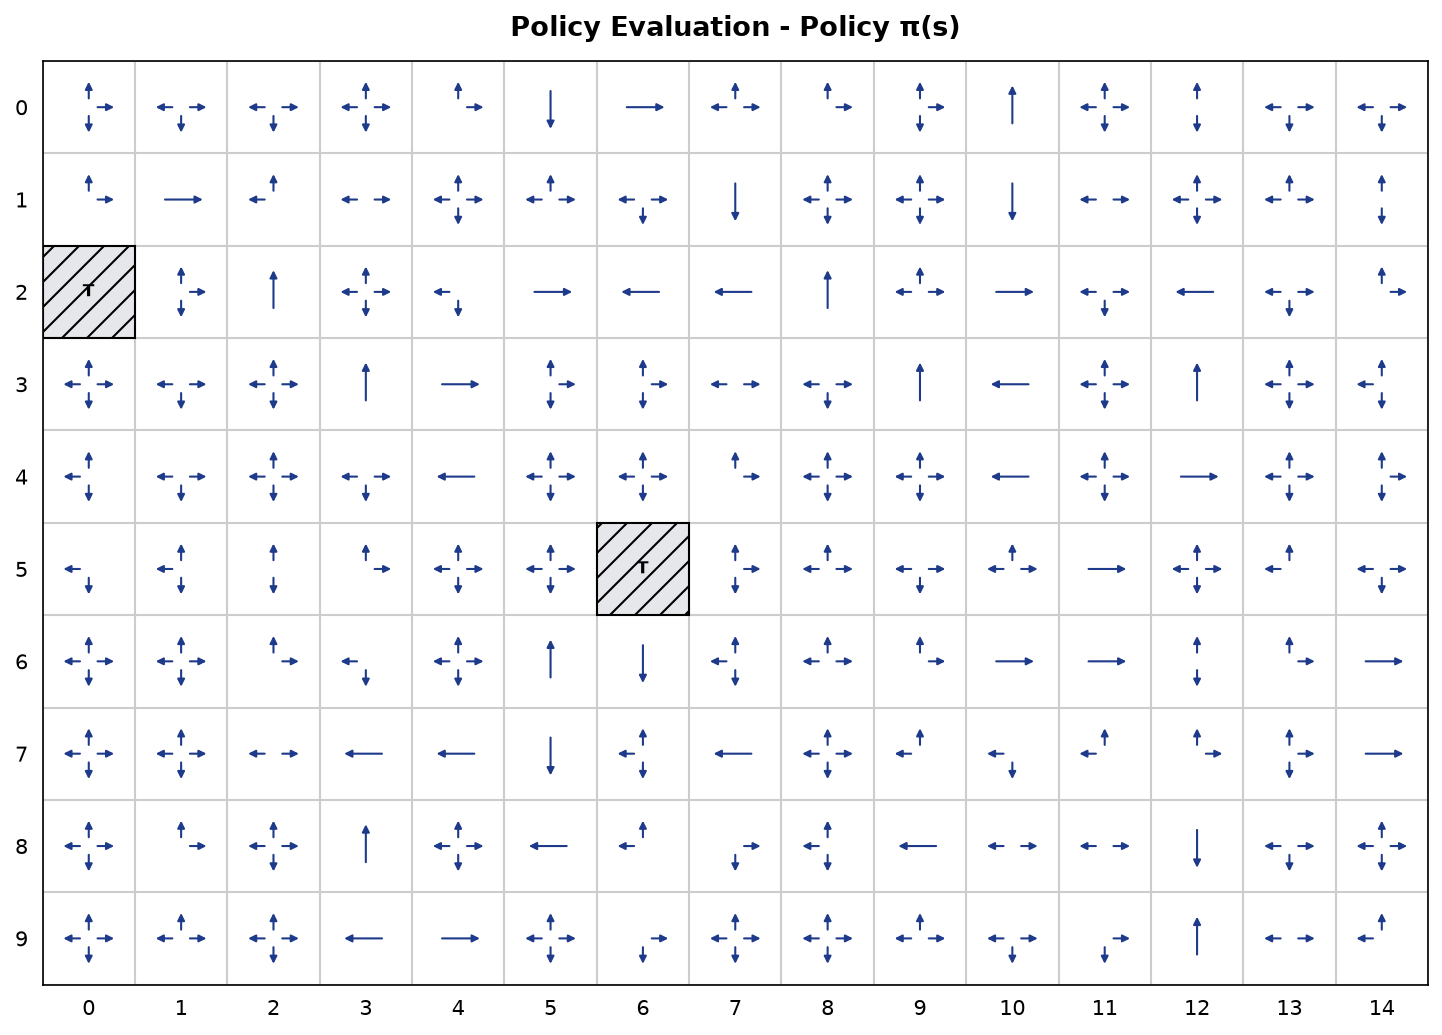

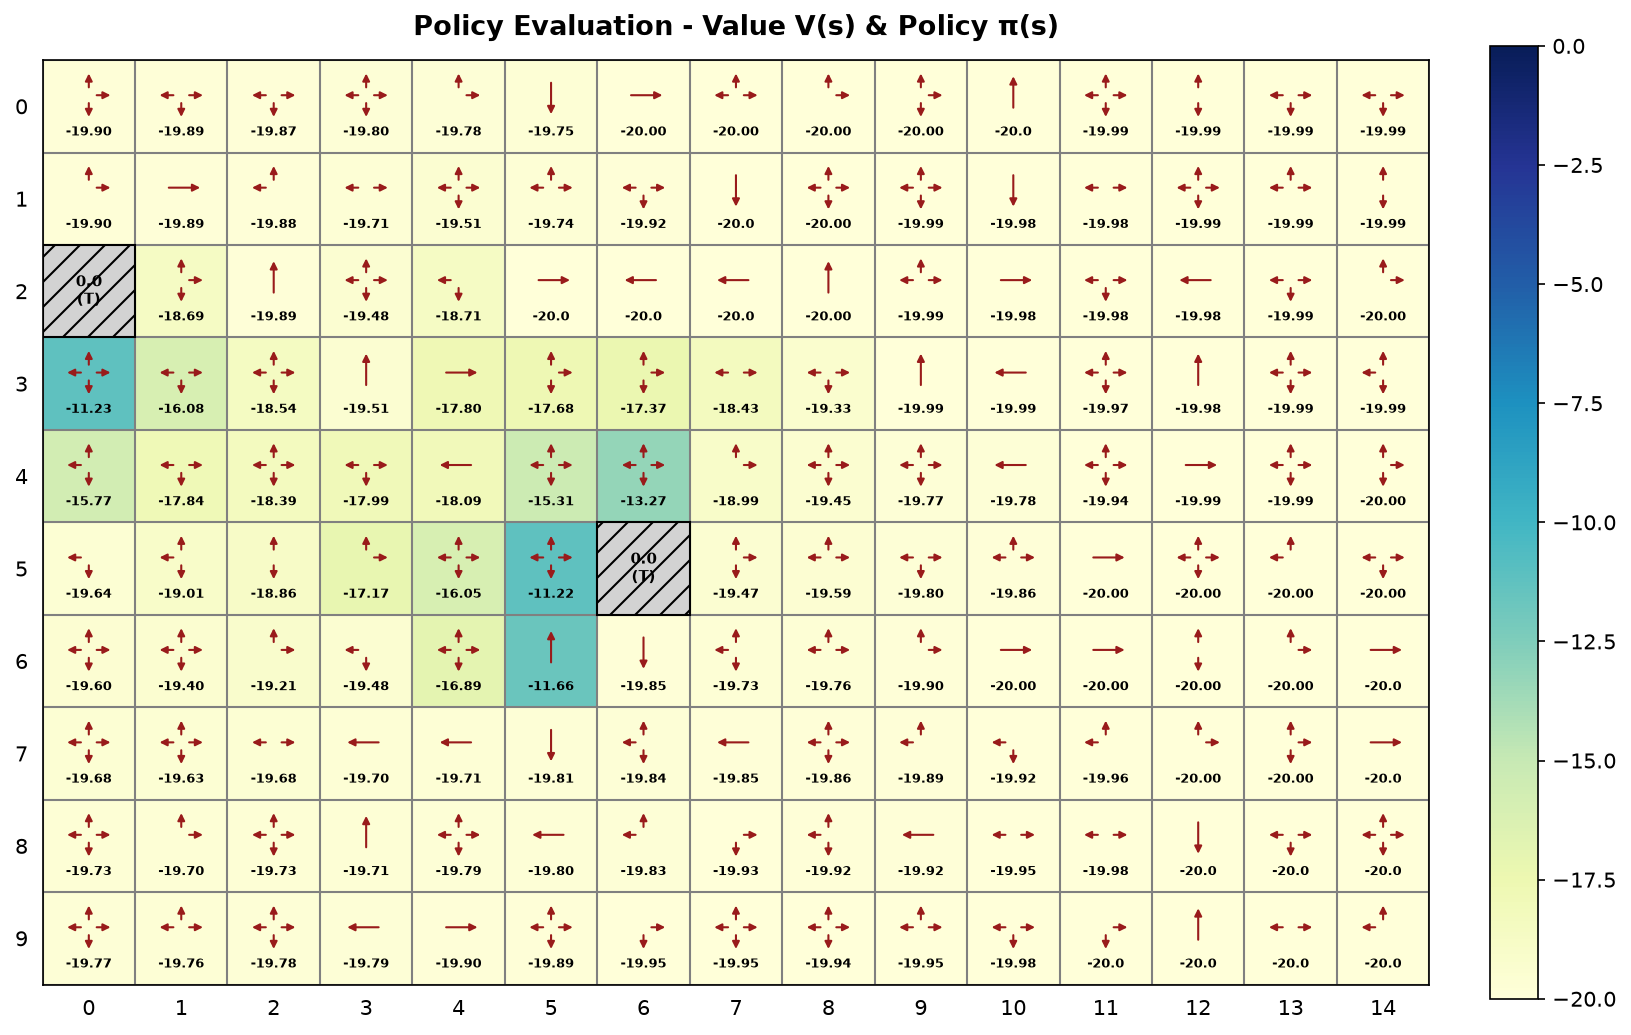

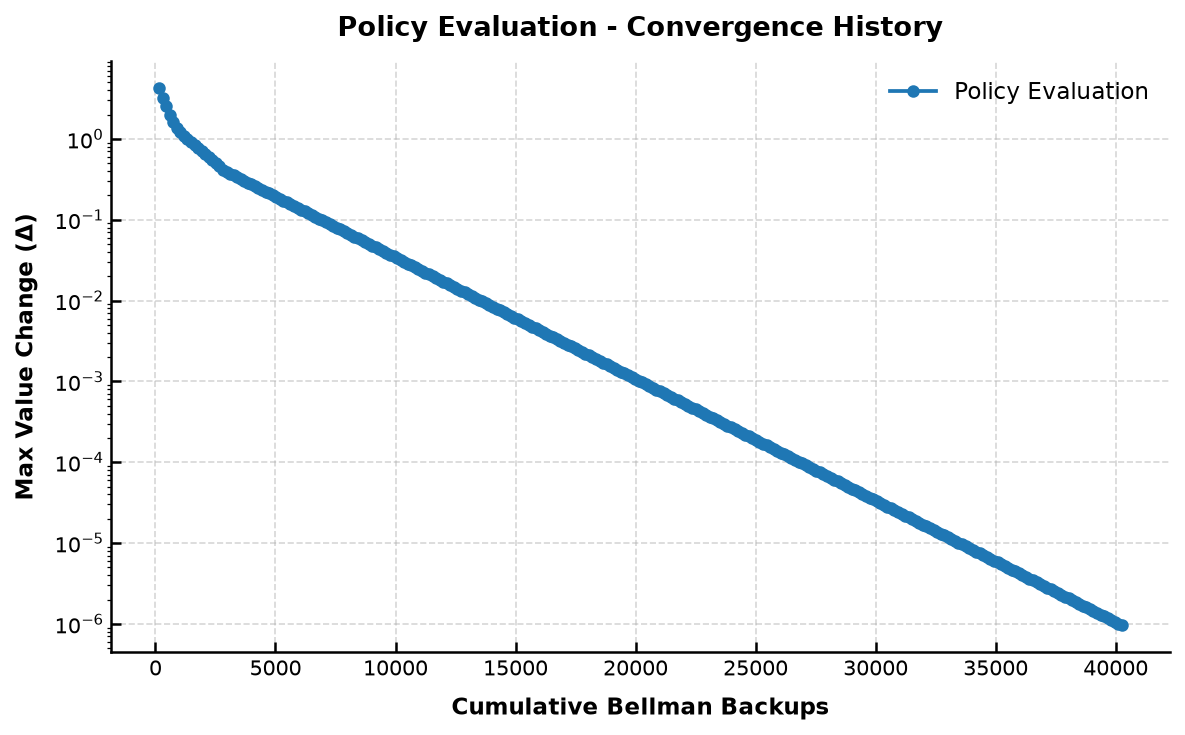

In [3]:
V_eval, eval_backups, eval_history = policy_evaluation(
    env=env,
    pi=pi,
    gamma=gamma,
    seed=seed,
)

print(f"Policy evaluation completed in {eval_backups} Bellman backups.")
print(f"Final delta value: {eval_history['delta'][-1]:.6f}")

fig1, ax1 = plot_value_grid(
    env,
    V_eval,
    title="Policy Evaluation - State-Value Function V(s)",
)
plt.show()

fig2, ax2 = plot_policy_arrows(
    env,
    pi,
    title="Policy Evaluation - Policy π(s)",
)
plt.show()

fig3, ax3 = plot_value_and_policy(
    env,
    V_eval,
    pi,
    title="Policy Evaluation - Value V(s) & Policy π(s)",
)
plt.show()

fig4, ax4 = plot_convergence_comparison(
    {"Policy Evaluation": eval_history},
    log_scale=True,
    title="Policy Evaluation - Convergence History",
)
plt.show()

## Remarks

Policy evaluation converged smoothly for the fixed policy, and the value function stabilized after about 40k Bellman backups. The final values are consistent with the deterministic step cost structure, with most states settling near the same negative range and the terminal states remaining fixed at zero.